# EnergyLens-AI - Notebook 1: EDA

Before doing any cleaning or modeling, I wanted to understand the data first. This notebook is just exploration - checking shapes, missing values, distributions, and how weather relates to consumption.

What I did here:
1. Uploaded all three datasets (households, weather, daily consumption)
2. Checked data types, shapes and missing values
3. Looked at consumption patterns across day / week / season
4. Checked how weather affects consumption
5. Looked at household demographics (ACORN groups, tariff types)
6. Noted down what I found so I know what to do in the cleaning notebook


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 2. Household Information

This file has the household metadata - which ACORN group each household belongs to and what tariff (standard or time-of-use) they are on.


In [2]:
# Upload household info file
from google.colab import files
print("📤 Please upload: informations_households.csv")
uploaded_hh = files.upload()


📤 Please upload: informations_households.csv


Saving informations_households.csv to informations_households.csv


In [3]:
# Load household data
hh_filename = list(uploaded_hh.keys())[0]
households = pd.read_csv(hh_filename)

print(f"Shape: {households.shape}")
print(f"\nColumns: {list(households.columns)}")
print(f"\nData types:\n{households.dtypes}")
print(f"\nFirst 5 rows:")
households.head()


Shape: (5566, 5)

Columns: ['LCLid', 'stdorToU', 'Acorn', 'Acorn_grouped', 'file']

Data types:
LCLid            object
stdorToU         object
Acorn            object
Acorn_grouped    object
file             object
dtype: object

First 5 rows:


,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


In [4]:
# Quick summary of household data
print("=" * 60)
print("HOUSEHOLD METADATA SUMMARY")
print("=" * 60)
print(f"\n📊 Total households: {households.shape[0]}")

if 'Acorn' in households.columns:
    print(f"\n🏷️ Unique ACORN groups: {households['Acorn'].nunique()}")

if 'stdorToU' in households.columns:
    print(f"\n💰 Tariff types:")
    print(households['stdorToU'].value_counts().to_string())

print(f"\n❓ Missing values:\n{households.isnull().sum()}")


HOUSEHOLD METADATA SUMMARY

📊 Total households: 5566

🏷️ Unique ACORN groups: 19

💰 Tariff types:
stdorToU
Std    4443
ToU    1123

❓ Missing values:
LCLid            0
stdorToU         0
Acorn            0
Acorn_grouped    0
file             0
dtype: int64


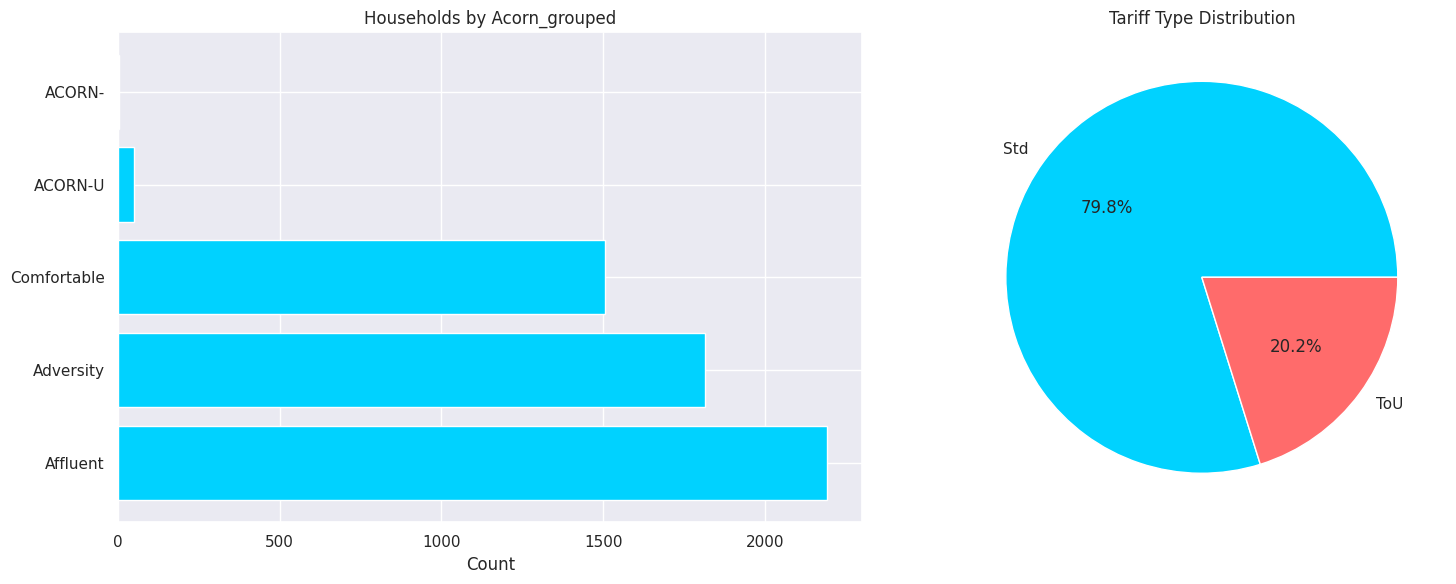

In [5]:
# Plot ACORN groups and tariff split
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

acorn_col = 'Acorn_grouped' if 'Acorn_grouped' in households.columns else 'Acorn'
if acorn_col in households.columns:
    acorn_counts = households[acorn_col].value_counts()
    axes[0].barh(acorn_counts.index, acorn_counts.values, color='#00d2ff')
    axes[0].set_title(f'Households by {acorn_col}')
    axes[0].set_xlabel('Count')

if 'stdorToU' in households.columns:
    tariff_counts = households['stdorToU'].value_counts()
    axes[1].pie(tariff_counts.values, labels=tariff_counts.index,
                autopct='%1.1f%%', colors=['#00d2ff', '#ff6b6b'])
    axes[1].set_title('Tariff Type Distribution')

plt.tight_layout()
plt.show()


## 3. Weather Data

Energy use depends a lot on weather, especially temperature, so I checked this dataset next.


In [6]:
# Upload weather file
print("📤 Please upload: weather_daily_darksky.csv")
uploaded_weather = files.upload()


📤 Please upload: weather_daily_darksky.csv


Saving weather_daily_darksky.csv to weather_daily_darksky.csv


In [7]:
weather_filename = list(uploaded_weather.keys())[0]
weather_daily = pd.read_csv(weather_filename)

print(f"Shape: {weather_daily.shape}")
print(f"\nColumns ({len(weather_daily.columns)}):\n{list(weather_daily.columns)}")
print(f"\nData types:\n{weather_daily.dtypes}")
print(f"\nMissing values (top 10):\n{weather_daily.isnull().sum().sort_values(ascending=False).head(10)}")
print("\nBasic statistics:")
weather_daily.describe()


Shape: (882, 32)

Columns (32):
['temperatureMax', 'temperatureMaxTime', 'windBearing', 'icon', 'dewPoint', 'temperatureMinTime', 'cloudCover', 'windSpeed', 'pressure', 'apparentTemperatureMinTime', 'apparentTemperatureHigh', 'precipType', 'visibility', 'humidity', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureMax', 'uvIndex', 'time', 'sunsetTime', 'temperatureLow', 'temperatureMin', 'temperatureHigh', 'sunriseTime', 'temperatureHighTime', 'uvIndexTime', 'summary', 'temperatureLowTime', 'apparentTemperatureMin', 'apparentTemperatureMaxTime', 'apparentTemperatureLowTime', 'moonPhase']

Data types:
temperatureMax                 float64
temperatureMaxTime              object
windBearing                      int64
icon                            object
dewPoint                       float64
temperatureMinTime              object
cloudCover                     float64
windSpeed                      float64
pressure                       float64
apparentTemper

,temperatureMax,windBearing,dewPoint,cloudCover,windSpeed,pressure,apparentTemperatureHigh,visibility,humidity,apparentTemperatureLow,apparentTemperatureMax,uvIndex,temperatureLow,temperatureMin,temperatureHigh,apparentTemperatureMin,moonPhase
count,882.000000,882.000000,882.000000,881.000000,882.000000,882.000000,882.000000,882.000000,882.000000,882.000000,882.000000,881.000000,882.000000,882.000000,882.000000,882.000000,882.000000
mean,13.660113,195.702948,6.530034,0.477605,3.581803,1014.127540,12.723866,11.167143,0.781871,6.085045,12.929467,2.542565,7.709841,7.414161,13.542392,5.738039,0.500930
std,6.182744,89.340783,4.830875,0.193514,1.694007,11.073038,7.279168,2.466109,0.095348,6.031967,7.105426,1.832985,4.871004,4.888852,6.260196,6.048746,0.287022
min,-0.060000,0.000000,-7.840000,0.000000,0.200000,979.250000,-6.460000,1.480000,0.430000,-8.880000,-4.110000,0.000000,-5.640000,-5.640000,-0.810000,-8.880000,0.000000
25%,9.502500,120.500000,3.180000,0.350000,2.370000,1007.435000,7.032500,10.327500,0.720000,1.522500,7.332500,1.000000,3.990000,3.705000,9.212500,1.105000,0.260000
50%,12.625000,219.000000,6.380000,0.470000,3.440000,1014.615000,12.470000,11.970000,0.790000,5.315000,12.625000,2.000000,7.540000,7.100000,12.470000,4.885000,0.500000
75%,17.920000,255.000000,10.057500,0.600000,4.577500,1021.755000,17.910000,12.830000,0.860000,11.467500,17.920000,4.000000,11.467500,11.277500,17.910000,11.277500,0.750000
max,32.400000,359.000000,17.770000,1.000000,9.960000,1040.920000,32.420000,15.340000,0.980000,20.540000,32.420000,7.000000,20.540000,20.540000,32.400000,20.540000,0.990000


In [8]:
# Parse date column
date_col = [c for c in weather_daily.columns if 'time' in c.lower() and 'max' not in c.lower() and 'min' not in c.lower() and 'high' not in c.lower() and 'low' not in c.lower() and 'sunrise' not in c.lower() and 'sunset' not in c.lower() and 'uv' not in c.lower() and 'apparent' not in c.lower()]
if not date_col:
    date_col = [c for c in weather_daily.columns if c.lower() == 'time']
if date_col:
    weather_daily[date_col[0]] = pd.to_datetime(weather_daily[date_col[0]])
    print(f"Date column: {date_col[0]}")
    print(f"Date range: {weather_daily[date_col[0]].min()} to {weather_daily[date_col[0]].max()}")
    print(f"Total days: {(weather_daily[date_col[0]].max() - weather_daily[date_col[0]].min()).days}")
else:
    print("⚠️ No date column found automatically. Check columns above.")


Date column: time
Date range: 2011-11-01 00:00:00 to 2014-03-30 23:00:00
Total days: 880


In [9]:
# Plot temperature trend
if date_col:
    temp_cols = [c for c in weather_daily.columns if 'temperaturemax' == c.lower()]
    if not temp_cols:
        temp_cols = [c for c in weather_daily.columns if 'temp' in c.lower() and weather_daily[c].dtype in ['float64','int64']]
    if temp_cols:
        fig = px.line(weather_daily.sort_values(date_col[0]), x=date_col[0], y=temp_cols[0],
                      title='Daily Temperature Trend — London',
                      labels={date_col[0]: 'Date', temp_cols[0]: 'Temperature (°C)'})
        fig.update_layout(template='plotly_dark')
        fig.show()


## 4. Daily Consumption Data

This is the aggregated per-household per-day dataset. It's much lighter to work with than the half-hourly data, so I used this for most of the EDA.


In [10]:
# Upload daily consumption file(s)
print("📤 Please upload: daily_dataset.csv")
print("   (If you have multiple block files, upload them one by one)")
uploaded_daily = files.upload()


📤 Please upload: daily_dataset.csv
   (If you have multiple block files, upload them one by one)


Saving daily_dataset.csv to daily_dataset.csv


In [11]:
# Load daily consumption data
daily_frames = []
for fname, content in uploaded_daily.items():
    print(f"Loading: {fname}")
    df = pd.read_csv(fname)
    daily_frames.append(df)
    print(f"  Shape: {df.shape}")

daily = pd.concat(daily_frames, ignore_index=True)
print(f"\n✅ Combined daily dataset shape: {daily.shape}")
print(f"Columns: {list(daily.columns)}")
print(f"\nData types:\n{daily.dtypes}")
print(f"\nMissing values:\n{daily.isnull().sum()}")
print(f"\nFirst 5 rows:")
daily.head()


Loading: daily_dataset.csv
  Shape: (3510433, 9)

✅ Combined daily dataset shape: (3510433, 9)
Columns: ['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min']

Data types:
LCLid             object
day               object
energy_median    float64
energy_mean      float64
energy_max       float64
energy_count       int64
energy_std       float64
energy_sum       float64
energy_min       float64
dtype: object

Missing values:
LCLid                0
day                  0
energy_median       30
energy_mean         30
energy_max          30
energy_count         0
energy_std       11331
energy_sum          30
energy_min          30
dtype: int64

First 5 rows:


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066


In [12]:
# Basic stats for daily consumption
numeric_cols = daily.select_dtypes(include=[np.number]).columns.tolist()
print("📊 Daily Consumption — Statistical Summary:")
print("=" * 60)
print(daily[numeric_cols].describe())
print(f"\n📐 Unique households: {daily.iloc[:, 0].nunique()}")


📊 Daily Consumption — Statistical Summary:
       energy_median   energy_mean    energy_max  energy_count    energy_std  \
count   3.510403e+06  3.510403e+06  3.510403e+06  3.510433e+06  3.499102e+06   
mean    1.587395e-01  2.117305e-01  8.345210e-01  4.780364e+01  1.726673e-01   
std     1.701865e-01  1.908460e-01  6.683156e-01  2.810982e+00  1.531208e-01   
min     0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%     6.700000e-02  9.808333e-02  3.460000e-01  4.800000e+01  6.911626e-02   
50%     1.145000e-01  1.632917e-01  6.880000e-01  4.800000e+01  1.327910e-01   
75%     1.910000e-01  2.624583e-01  1.128000e+00  4.800000e+01  2.293124e-01   
max     6.970500e+00  6.928250e+00  1.076100e+01  4.800000e+01  4.024569e+00   

         energy_sum    energy_min  
count  3.510403e+06  3.510403e+06  
mean   1.012414e+01  5.962578e-02  
std    9.128793e+00  8.701312e-02  
min    0.000000e+00  0.000000e+00  
25%    4.682000e+00  2.000000e-02  
50%    7.815000e+00 

## 5. Consumption Distribution

I checked whether the target looks skewed or roughly normal, since that affects which models make sense later. Tree-based models can handle skew fine, but linear regression works better when the target is closer to normal.


Potential energy columns: ['energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min']


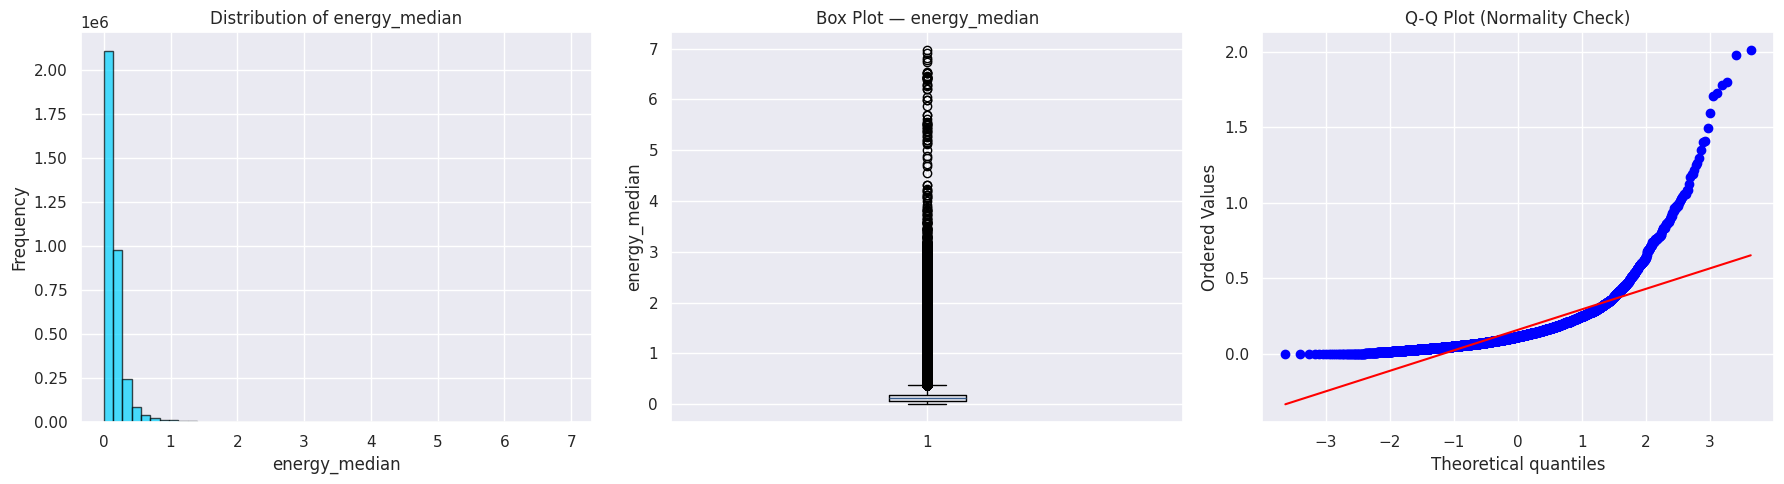


📊 Skewness: 5.1691
📊 Kurtosis: 58.9847
⚠️ Highly skewed — consider log transformation for linear models


In [13]:
# Find energy column
energy_cols = [c for c in daily.columns if any(
    kw in c.lower() for kw in ['energy', 'kwh', 'consumption', 'sum', 'mean']
)]
print(f"Potential energy columns: {energy_cols}")

if energy_cols:
    target_col = energy_cols[0]
    data = daily[target_col].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram
    axes[0].hist(data, bins=50, color='#00d2ff', edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Distribution of {target_col}')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Frequency')

    # Box plot
    axes[1].boxplot(data, vert=True)
    axes[1].set_title(f'Box Plot — {target_col}')
    axes[1].set_ylabel(target_col)

    # QQ plot
    from scipy import stats
    stats.probplot(data.sample(min(5000, len(data)), random_state=42), plot=axes[2])
    axes[2].set_title('Q-Q Plot (Normality Check)')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Skewness: {data.skew():.4f}")
    print(f"📊 Kurtosis: {data.kurtosis():.4f}")
    if abs(data.skew()) > 1:
        print("⚠️ Highly skewed — consider log transformation for linear models")
    else:
        print("✅ Moderate skewness — no transformation strictly needed")


## 6. Time-Series Trends

Consumption should have daily, weekly and seasonal patterns. I plotted these separately to see what's actually going on before deciding what time-based features to build later.


In [14]:
# Parse date column in daily data
date_candidates = [c for c in daily.columns if any(kw in c.lower() for kw in ['date', 'day', 'time'])]
print(f"Date column candidates: {date_candidates}")

if date_candidates and energy_cols:
    daily[date_candidates[0]] = pd.to_datetime(daily[date_candidates[0]], errors='coerce')

    # Aggregate across all households by day
    daily_agg = daily.groupby(date_candidates[0])[energy_cols[0]].mean().reset_index()
    daily_agg.columns = ['date', 'avg_consumption']
    daily_agg = daily_agg.sort_values('date')

    fig = px.line(daily_agg, x='date', y='avg_consumption',
                  title='Average Daily Consumption Across All Households',
                  labels={'date': 'Date', 'avg_consumption': 'Avg Consumption (kWh)'})
    fig.update_layout(template='plotly_dark')
    fig.show()


Date column candidates: ['day']


In [15]:
# Monthly average consumption
if date_candidates and energy_cols:
    daily_agg['month'] = daily_agg['date'].dt.month
    daily_agg['year'] = daily_agg['date'].dt.year
    daily_agg['month_name'] = daily_agg['date'].dt.month_name()

    monthly = daily_agg.groupby(['year', 'month', 'month_name'])['avg_consumption'].mean().reset_index()

    fig = px.bar(monthly, x='month_name', y='avg_consumption', color='year',
                 barmode='group', title='Monthly Average Consumption by Year',
                 labels={'avg_consumption': 'Avg Consumption', 'month_name': 'Month'})
    fig.update_layout(template='plotly_dark')
    fig.show()


In [16]:
# Average consumption by day of week
if date_candidates and energy_cols:
    daily_agg['day_of_week'] = daily_agg['date'].dt.day_name()
    daily_agg['dow_num'] = daily_agg['date'].dt.dayofweek

    dow = daily_agg.groupby(['day_of_week', 'dow_num'])['avg_consumption'].mean().reset_index()
    dow = dow.sort_values('dow_num')

    fig = px.bar(dow, x='day_of_week', y='avg_consumption',
                 title='Average Consumption by Day of Week',
                 labels={'avg_consumption': 'Avg Consumption', 'day_of_week': 'Day'},
                 color='avg_consumption', color_continuous_scale='Viridis')
    fig.update_layout(template='plotly_dark')
    fig.show()

    print(f"\n💡 Highest consumption day: {dow.loc[dow['avg_consumption'].idxmax(), 'day_of_week']}")
    print(f"   Lowest consumption day: {dow.loc[dow['avg_consumption'].idxmin(), 'day_of_week']}")



💡 Highest consumption day: Sunday
   Lowest consumption day: Thursday


## 7. Weather vs Consumption

If temperature or other weather features correlate strongly with consumption, they need to go into the model as features.


In [17]:
if date_candidates and date_col and energy_cols:
    merged = daily_agg.merge(weather_daily, left_on='date', right_on=date_col[0], how='inner')
    weather_numeric = weather_daily.select_dtypes(include=[np.number]).columns.tolist()

    if weather_numeric:
        correlations = merged[['avg_consumption'] + weather_numeric].corr()['avg_consumption'].drop('avg_consumption')
        correlations = correlations.sort_values(ascending=False)

        print("🔗 Correlation with avg consumption:")
        print("=" * 50)
        for feat, corr in correlations.items():
            bar = '█' * int(abs(corr) * 20)
            direction = '+' if corr > 0 else '-'
            print(f"  {feat:>35s}: {direction}{abs(corr):.4f} {bar}")


🔗 Correlation with avg consumption:
                           cloudCover: +0.2144 ████
                             humidity: +0.0909 █
                            windSpeed: +0.0496 
                             pressure: +0.0302 
                            moonPhase: -0.0375 
                           visibility: -0.0660 █
                          windBearing: -0.1848 ███
                              uvIndex: -0.2470 ████
                       temperatureLow: -0.4230 ████████
               apparentTemperatureLow: -0.4680 █████████
                             dewPoint: -0.5146 ██████████
                       temperatureMin: -0.5382 ██████████
               apparentTemperatureMin: -0.6052 ████████████
               apparentTemperatureMax: -0.6460 ████████████
              apparentTemperatureHigh: -0.6479 ████████████
                       temperatureMax: -0.6791 █████████████
                      temperatureHigh: -0.6799 █████████████


In [18]:
# Temperature vs consumption scatter plot
if date_candidates and date_col and energy_cols:
    temp_cols_merged = [c for c in merged.columns if 'temp' in c.lower() and merged[c].dtype in ['float64','int64']]
    if temp_cols_merged:
        fig = px.scatter(merged, x=temp_cols_merged[0], y='avg_consumption',
                         title=f'{temp_cols_merged[0]} vs Average Daily Consumption',
                         labels={temp_cols_merged[0]: 'Temperature', 'avg_consumption': 'Avg Consumption'},
                         trendline='lowess', opacity=0.5)
        fig.update_layout(template='plotly_dark')
        fig.show()


## 8. Half-Hourly Data (Sample)

Loading just one block file here - enough to build an hour-of-day heatmap without loading everything.


In [19]:
# Upload one half-hourly block file
print("📤 Please upload ONE half-hourly block file (e.g., block_0.csv)")
print("   (Just one file is enough for the heatmap analysis)")
uploaded_hh_data = files.upload()


📤 Please upload ONE half-hourly block file (e.g., block_0.csv)
   (Just one file is enough for the heatmap analysis)


Saving block_15.csv to block_15.csv


In [20]:
hh_filename = list(uploaded_hh_data.keys())[0]
sample_hh = pd.read_csv(hh_filename)
print(f"Shape: {sample_hh.shape}")
print(f"Columns: {list(sample_hh.columns)}")
sample_hh.head()


Shape: (1580261, 3)
Columns: ['LCLid', 'tstp', 'energy(kWh/hh)']


,LCLid,tstp,energy(kWh/hh)
0,MAC000306,2012-03-05 12:30:00.0000000,0.283
1,MAC000306,2012-03-05 13:00:00.0000000,0.057
2,MAC000306,2012-03-05 13:30:00.0000000,0.099
3,MAC000306,2012-03-05 14:00:00.0000000,0.081
4,MAC000306,2012-03-05 14:30:00.0000000,0.118


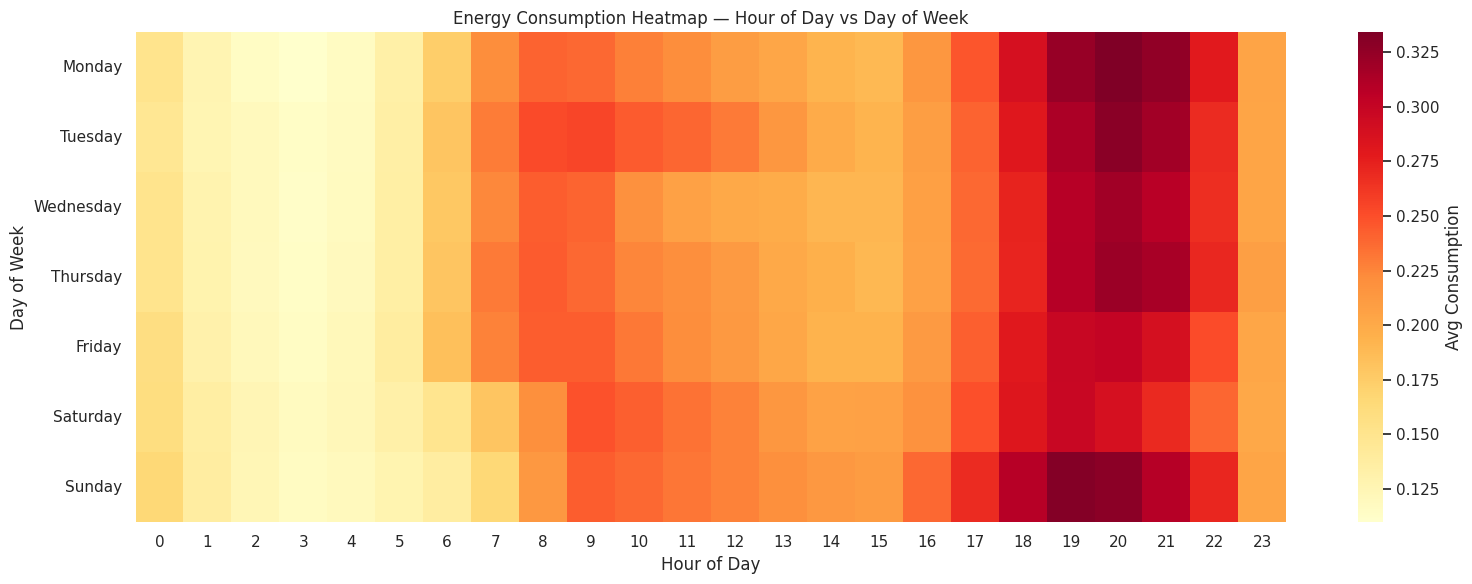

In [21]:
# Heatmap of consumption by hour and day of week
dt_col_hh = [c for c in sample_hh.columns if any(kw in c.lower() for kw in ['date', 'time', 'tstp'])]
en_col_hh = [c for c in sample_hh.columns if any(kw in c.lower() for kw in ['energy', 'kwh', 'consumption'])]

if dt_col_hh and en_col_hh:
    sample_hh[dt_col_hh[0]] = pd.to_datetime(sample_hh[dt_col_hh[0]], errors='coerce')
    sample_hh[en_col_hh[0]] = pd.to_numeric(sample_hh[en_col_hh[0]], errors='coerce')
    sample_hh = sample_hh.dropna(subset=[dt_col_hh[0], en_col_hh[0]])

    sample_hh['hour'] = sample_hh[dt_col_hh[0]].dt.hour
    sample_hh['dow_num'] = sample_hh[dt_col_hh[0]].dt.dayofweek

    heatmap_data = sample_hh.groupby(['dow_num', 'hour'])[en_col_hh[0]].mean().reset_index()
    heatmap_pivot = heatmap_data.pivot(index='dow_num', columns='hour', values=en_col_hh[0])

    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    heatmap_pivot.index = [day_names[i] for i in heatmap_pivot.index]

    plt.figure(figsize=(16, 6))
    sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Avg Consumption'})
    plt.title('Energy Consumption Heatmap — Hour of Day vs Day of Week')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Week')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find datetime/energy columns automatically.")


## 9. Missing Values Overview

Checking missing values in the daily dataset before deciding how to handle them in the cleaning notebook.


In [22]:
if not daily.empty:
    missing = daily.isnull().sum()
    missing_pct = (missing / len(daily) * 100).round(2)
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

    if len(missing_df) > 0:
        print("⚠️ Columns with missing values:")
        print("=" * 50)
        print(missing_df.to_string())

        fig = px.bar(missing_df, x=missing_df.index, y='Missing %',
                     title='Missing Values by Column (%)',
                     labels={'x': 'Column', 'Missing %': '% Missing'})
        fig.update_layout(template='plotly_dark')
        fig.show()
    else:
        print("✅ No missing values found in daily dataset!")


⚠️ Columns with missing values:
               Missing Count  Missing %
energy_std             11331       0.32
energy_median             30       0.00
energy_mean               30       0.00
energy_max                30       0.00
energy_sum                30       0.00
energy_min                30       0.00


## 10. Weather Correlation

Checking correlation between weather features so I don't end up using too many redundant features later.


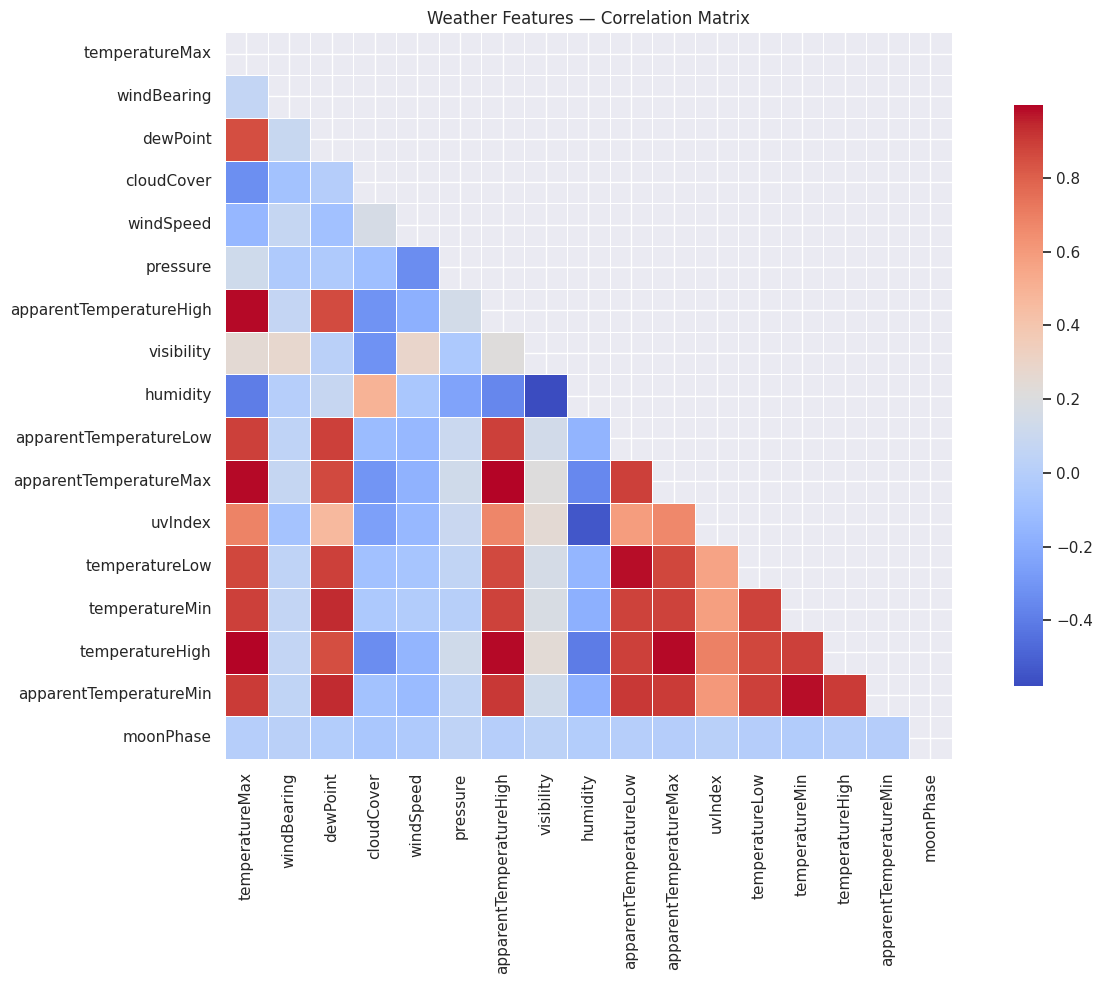

In [23]:
weather_num = weather_daily.select_dtypes(include=[np.number])
if len(weather_num.columns) > 0:
    plt.figure(figsize=(14, 10))
    corr = weather_num.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title('Weather Features — Correlation Matrix')
    plt.tight_layout()
    plt.show()


## 11. Summary of Findings

Here's what I found before moving to cleaning:

| Aspect | Finding | What it means for next steps |
|---|---|---|
| Dataset size | Daily: 3,510,433 rows x 9 cols; Weather: 882 rows x 32 cols; Households: 5,566 rows x 5 cols | Daily data is large, so preprocessing needs to be efficient |
| Date range | Daily: 2011-11-23 to 2014-02-28; Weather: 2011-11-01 to 2014-03-30 | Need to align date ranges before merging |
| Missing values | 0.32% missing in `energy_std` (11,331 rows), a few rows missing in other daily columns, 1 missing value in `cloudCover` | Missing % is small, simple imputation or dropping rows should be fine |
| Distribution | Skewness = 5.1691, Kurtosis = 58.9847 | Right-skewed, may need log transform for linear models |
| Seasonality | Clear seasonal pattern - winter peak around 0.45 kWh/hh/day, summer low around 0.28 kWh/hh/day | Need seasonal features (month, maybe Fourier terms) |
| Day-of-week effect | Yes - highest on Sunday, lowest on Thursday | Add day-of-week as a feature |
| Weather correlation | Strong negative correlation with temperature (r = -0.68 with `temperatureHigh`) | Temperature is an important feature for forecasting |
| ACORN variation | Households differ a lot in consumption depending on ACORN group | Useful as a feature, or for clustering later |

### Next steps (Notebook 2)
1. Handle missing values
2. Handle outliers
3. Merge all three datasets into one clean dataframe
4. Save the cleaned data for feature engineering
